In [28]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings("ignore")

# -------------------------------
# Configuration
# -------------------------------
project_root = Path("C:/JupyterProjects/Stock_ML_Project")
data_dir = project_root / "Data" / "Processed" / "enhanced"
results_dir = project_root / "Results"
results_dir.mkdir(parents=True, exist_ok=True)

tickers = {
    "RELIANCE": data_dir / "reliance_enhanced_model_ready.csv",
    "TCS": data_dir / "tcs_enhanced_model_ready.csv",
    "HDFCBANK": data_dir / "hdfcbank_enhanced_model_ready.csv"
}

models = {
    "LinearRegression": LinearRegression(),
    "DecisionTree": DecisionTreeRegressor(random_state=42),
    "RandomForest": RandomForestRegressor(n_estimators=100, random_state=42),
    "SVR": SVR(kernel='rbf')
}

# -------------------------------
# Helper
# -------------------------------
def evaluate_regression(y_true, y_pred):
    return {
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred)
    }

# -------------------------------
# Main Loop
# -------------------------------
results = []

for ticker, path in tickers.items():
    print(f"\n=== Processing {ticker} ===")
    if not path.exists():
        print(f"  ⚠️ Missing file: {path}")
        continue

    df = pd.read_csv(path)
    print(f"  Loaded dataset shape: {df.shape}")

    # --- Detect correct target column ---
    target_col = None
    for candidate in ["Target_Reg_y", "Target_Reg"]:
        if candidate in df.columns:
            target_col = candidate
            break

    if not target_col:
        print(f"  ⚠️ Skipping {ticker} — no Target_Reg column found.")
        continue
    else:
        print(f"  ✅ Using target column: {target_col}")

    # --- Clean and filter ---
    df = df.replace([np.inf, -np.inf], np.nan)

    # Keep numeric columns only
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    df_numeric = df[numeric_cols].copy()

    # Drop fully-empty columns
    df_numeric = df_numeric.dropna(axis=1, how='all')

    # Ensure target column is included
    if target_col not in df_numeric.columns and target_col in df.columns:
        df_numeric[target_col] = df[target_col]

    # Impute missing values (mean for numeric)
    imputer = SimpleImputer(strategy='mean')
    df_numeric[df_numeric.columns] = imputer.fit_transform(df_numeric)

    # Separate X and y
    y = df_numeric[target_col]
    X = df_numeric.drop(columns=[target_col], errors="ignore")

    if X.empty or y.empty:
        print(f"  ⚠️ Skipping {ticker} — insufficient valid samples.")
        continue

    # --- Split and Train ---
    X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False, test_size=0.2)

    for name, model in models.items():
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        metrics = evaluate_regression(y_test, preds)
        metrics.update({"Ticker": ticker, "Model": name})
        results.append(metrics)

        print(f"  → {name}: RMSE={metrics['RMSE']:.4f}, MAE={metrics['MAE']:.4f}, R2={metrics['R2']:.4f}")

# -------------------------------
# Save Results
# -------------------------------
if results:
    results_df = pd.DataFrame(results)
    save_path = results_dir / "enhanced_regression_results_final.csv"
    results_df.to_csv(save_path, index=False)
    print("\n✅ Completed. Results saved to:", save_path)
    display(results_df.sort_values(["Ticker", "RMSE"]))
else:
    print("\n⚠️ No valid results to display.")



=== Processing RELIANCE ===
  Loaded dataset shape: (1460, 25)
  ✅ Using target column: Target_Reg
  → LinearRegression: RMSE=17.5853, MAE=12.7372, R2=0.9771
  → DecisionTree: RMSE=197.7049, MAE=167.4119, R2=-1.8904
  → RandomForest: RMSE=180.2454, MAE=151.5391, R2=-1.4024
  → SVR: RMSE=327.7345, MAE=304.8417, R2=-6.9426

=== Processing TCS ===
  Loaded dataset shape: (1460, 25)
  ✅ Using target column: Target_Reg
  → LinearRegression: RMSE=52.0209, MAE=37.1007, R2=0.9709
  → DecisionTree: RMSE=652.8521, MAE=580.3555, R2=-3.5758
  → RandomForest: RMSE=539.8757, MAE=470.1992, R2=-2.1291
  → SVR: RMSE=951.6448, MAE=903.4043, R2=-8.7227

=== Processing HDFCBANK ===
  Loaded dataset shape: (1460, 25)
  ✅ Using target column: Target_Reg
  → LinearRegression: RMSE=9.5666, MAE=6.8599, R2=0.9773
  → DecisionTree: RMSE=40.5684, MAE=29.9313, R2=0.5909
  → RandomForest: RMSE=35.3147, MAE=23.7118, R2=0.6900
  → SVR: RMSE=77.1135, MAE=61.9644, R2=-0.4782

✅ Completed. Results saved to: C:\JupyterP

,RMSE,MAE,R2,Ticker,Model
8,9.566634,6.859892,0.977250,HDFCBANK,LinearRegression
10,35.314659,23.711826,0.689995,HDFCBANK,RandomForest
9,40.568369,29.931323,0.590896,HDFCBANK,DecisionTree
11,77.113483,61.964442,-0.478151,HDFCBANK,SVR
0,17.585252,12.737170,0.977133,RELIANCE,LinearRegression
2,180.245385,151.539114,-1.402422,RELIANCE,RandomForest
1,197.704904,167.411946,-1.890386,RELIANCE,DecisionTree
3,327.734527,304.841685,-6.942648,RELIANCE,SVR
4,52.020905,37.100713,0.970947,TCS,LinearRegression
6,539.875723,470.199221,-2.129125,TCS,RandomForest


In [27]:
import pandas as pd
from pathlib import Path

# Path to your enhanced file
file_path = Path("C:/JupyterProjects/Stock_ML_Project/Data/Processed/enhanced/reliance_enhanced_model_ready.csv")

# Load and show first few rows and column names
df = pd.read_csv(file_path)
print("✅ Loaded:", file_path)
print("\nColumns:\n", df.columns.tolist())
print("\nFirst 5 rows:")
display(df.head())


✅ Loaded: C:\JupyterProjects\Stock_ML_Project\Data\Processed\enhanced\reliance_enhanced_model_ready.csv

Columns:
 ['RELIANCE.NS_Return', 'RELIANCE.NS_MA7', 'RELIANCE.NS_MA21', 'RELIANCE.NS_EMA21', 'RELIANCE.NS_STD21', 'RELIANCE.NS_RSI', 'Target_Reg', 'Target_Cls', 'Split', 'Date', 'RELIANCE_Return_3', 'RELIANCE_Return_5', 'RELIANCE_Return_10', 'RELIANCE_Volatility_7', 'RELIANCE_Volatility_14', 'RELIANCE_Momentum_5', 'RELIANCE_Momentum_10', 'RELIANCE_BB_upper', 'RELIANCE_BB_lower', 'RELIANCE_BB_width', 'NIFTY_Close', 'NIFTY_Return', 'NIFTY_MA7', 'NIFTY_MA21', 'NIFTY_RSI']

First 5 rows:


,RELIANCE.NS_Return,RELIANCE.NS_MA7,RELIANCE.NS_MA21,RELIANCE.NS_EMA21,RELIANCE.NS_STD21,RELIANCE.NS_RSI,Target_Reg,Target_Cls,Split,Date,...,RELIANCE_Momentum_5,RELIANCE_Momentum_10,RELIANCE_BB_upper,RELIANCE_BB_lower,RELIANCE_BB_width,NIFTY_Close,NIFTY_Return,NIFTY_MA7,NIFTY_MA21,NIFTY_RSI
0,-0.015371,548.409572,513.682921,522.827247,26.790804,71.994823,531.708435,0,Train,2019-01-01,...,3.979902,21.449585,550.848793,543.302243,7.546550,10652.200195,0.0,10652.200195,10652.200195,0.0
1,-0.012349,545.741464,515.264724,523.634628,26.829565,68.467338,545.693909,1,Train,2019-01-02,...,3.979902,21.449585,550.848793,543.302243,7.546550,10652.200195,0.0,10652.200195,10652.200195,0.0
2,0.026303,545.233268,517.821661,525.640017,27.059029,74.750817,555.832520,1,Train,2019-01-03,...,3.979902,21.449585,549.873763,543.049106,6.824656,10652.200195,0.0,10652.200195,10652.200195,0.0
3,0.018579,546.735648,521.150434,528.384790,27.238542,77.120585,574.042419,1,Train,2019-01-04,...,3.979902,21.449585,549.329604,543.730372,5.599232,10652.200195,0.0,10652.200195,10652.200195,0.0
4,0.032761,549.495867,525.221409,532.535484,28.483007,77.758660,574.331421,1,Train,2019-01-05,...,3.979902,21.449585,550.716983,543.529344,7.187639,10652.200195,0.0,10652.200195,10652.200195,0.0


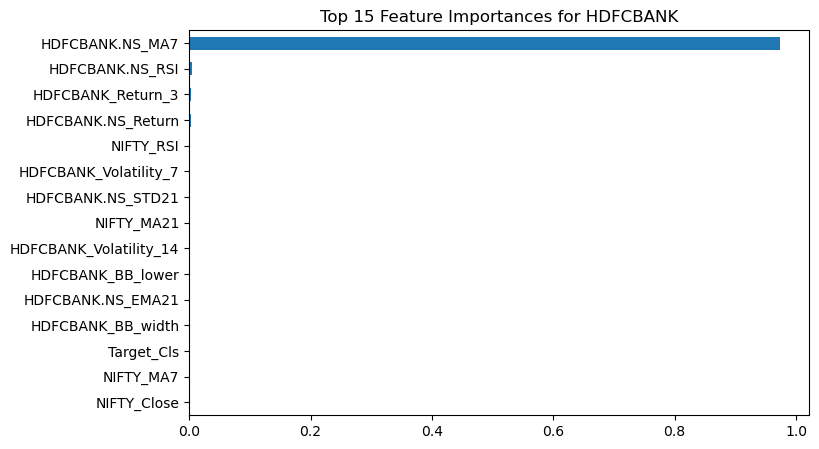


Top 15 Features:
 HDFCBANK.NS_MA7           0.973072
HDFCBANK.NS_RSI           0.004274
HDFCBANK_Return_3         0.003677
HDFCBANK.NS_Return        0.002622
NIFTY_RSI                 0.001813
HDFCBANK_Volatility_7     0.001568
HDFCBANK.NS_STD21         0.001529
NIFTY_MA21                0.001403
HDFCBANK_Volatility_14    0.001191
HDFCBANK_BB_lower         0.001048
HDFCBANK.NS_EMA21         0.000816
HDFCBANK_BB_width         0.000813
Target_Cls                0.000775
NIFTY_MA7                 0.000751
NIFTY_Close               0.000703
dtype: float64


In [29]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt

# Path setup
data_dir = Path("C:/JupyterProjects/Stock_ML_Project/Data/Processed/enhanced")
ticker = "HDFCBANK"  # You can change to RELIANCE or TCS to check others
path = data_dir / f"{ticker.lower()}_enhanced_model_ready.csv"

# Load data
df = pd.read_csv(path)
target_col = "Target_Reg"

# Prepare numeric data
df = df.replace([np.inf, -np.inf], np.nan)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df = df[numeric_cols].dropna(axis=1, how='all')

imputer = SimpleImputer(strategy="mean")
df[df.columns] = imputer.fit_transform(df)

X = df.drop(columns=[target_col], errors="ignore")
y = df[target_col]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False, test_size=0.2)

# Fit Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Feature importance
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
top_features = importances.head(15)

plt.figure(figsize=(8, 5))
top_features.plot(kind="barh")
plt.title(f"Top 15 Feature Importances for {ticker}")
plt.gca().invert_yaxis()
plt.show()

print("\nTop 15 Features:\n", top_features)


In [31]:
import pandas as pd
from pathlib import Path

# Paths
project_root = Path("C:/JupyterProjects/Stock_ML_Project")
results_dir = project_root / "Results"

# Load results
basic_path = results_dir / "regression_results.csv"  # your earlier results file
enhanced_path = results_dir / "enhanced_regression_results_final.csv"

basic = pd.read_csv(basic_path)
enhanced = pd.read_csv(enhanced_path)

# Merge on ticker + model
comparison = pd.merge(
    basic, enhanced,
    on=["Ticker", "Model"],
    suffixes=("_basic", "_enhanced")
)

# Compute improvements (lower RMSE & MAE, higher R² = better)
comparison["Δ_RMSE"] = comparison["RMSE_basic"] - comparison["RMSE_enhanced"]
comparison["Δ_MAE"] = comparison["MAE_basic"] - comparison["MAE_enhanced"]
comparison["Δ_R2"] = comparison["R2_enhanced"] - comparison["R2_basic"]

# Display sorted by improvement
display(comparison.sort_values(["Ticker", "Δ_R2"], ascending=[True, False]))

save_path = results_dir / "regression_comparison_basic_vs_enhanced.csv"
comparison.to_csv(save_path, index=False)
print(f"\n✅ Comparison saved to: {save_path}")


,Ticker,Model,MAE_basic,RMSE_basic,R2_basic,TrainRows,TestRows,RMSE_enhanced,MAE_enhanced,R2_enhanced,Δ_RMSE,Δ_MAE,Δ_R2
6,HDFCBANK,LinearRegression,10.573950,14.321181,0.949018,1168,292,9.566634,6.859892,0.977250,4.754548,3.714058,0.028232
8,HDFCBANK,RandomForest,23.768494,35.222402,0.691613,1168,292,35.314659,23.711826,0.689995,-0.092257,0.056668,-0.001618
7,HDFCBANK,DecisionTree,27.965709,38.467151,0.632178,1168,292,40.568369,29.931323,0.590896,-2.101217,-1.965613,-0.041281
0,RELIANCE,LinearRegression,18.576166,24.424498,0.955886,1168,292,17.585252,12.737170,0.977133,6.839246,5.838995,0.021246
2,RELIANCE,RandomForest,142.676245,171.093790,-1.164659,1168,292,180.245385,151.539114,-1.402422,-9.151595,-8.862869,-0.237763
1,RELIANCE,DecisionTree,142.588771,168.794178,-1.106861,1168,292,197.704904,167.411946,-1.890386,-28.910726,-24.823176,-0.783525
3,TCS,LinearRegression,56.791238,73.022208,0.942754,1168,292,52.020905,37.100713,0.970947,21.001303,19.690525,0.028193
5,TCS,RandomForest,431.538894,500.803339,-1.692587,1168,292,539.875723,470.199221,-2.129125,-39.072383,-38.660327,-0.436538
4,TCS,DecisionTree,441.700867,519.044507,-1.892308,1168,292,652.852102,580.355517,-3.575777,-133.807595,-138.654651,-1.683470



✅ Comparison saved to: C:\JupyterProjects\Stock_ML_Project\Results\regression_comparison_basic_vs_enhanced.csv
